# K-means Clustering

Notebook này ghi chú kiến thức về thuật toán **K-means** trong Machine Learning.

Nội dung chính:

1. K-means là gì?
2. Ý tưởng của thuật toán
3. Công thức toán học quan trọng
4. Các bước hoạt động
5. Ví dụ tính tay đơn giản
6. Demo Python với dữ liệu giả lập
7. Chọn số cụm bằng **Elbow Method**
8. Chọn số cụm bằng **Silhouette Score**
9. Demo Customer Segmentation
10. Ưu điểm, nhược điểm và khi nào nên dùng

---

## 1. K-means là gì?

**K-means** là một thuật toán thuộc nhóm **Unsupervised Learning**.

Nó dùng để **chia dữ liệu thành nhiều nhóm**, gọi là **clusters**, dựa trên mức độ giống nhau giữa các điểm dữ liệu.

Ví dụ:

- Nhóm khách hàng có thu nhập thấp nhưng chi tiêu cao
- Nhóm khách hàng có thu nhập cao nhưng chi tiêu thấp
- Nhóm học sinh có điểm Toán và điểm Anh giống nhau
- Nhóm sản phẩm có hành vi mua tương tự nhau

Điểm quan trọng:

> K-means không cần nhãn dữ liệu trước.  
> Model tự tìm nhóm dựa trên khoảng cách giữa các điểm.

## 2. Ý tưởng của thuật toán
K-means hoạt động theo logic rất đơn giản:
Chọn số cụm K.
- Tạo ngẫu nhiên K điểm trung tâm gọi là centroids.
- Mỗi điểm dữ liệu sẽ được gán vào centroid gần nhất.
- Cập nhật lại centroid bằng trung bình của các điểm trong cụm.
- Lặp lại bước 3 và 4 cho đến khi cụm ổn định.
Nói đơn giản: Điểm nào gần nhau thì gom vào chung một nhóm.

## 3. Cluster và Centroid

### Cluster là gì?

**Cluster** là một nhóm các điểm dữ liệu có đặc điểm gần giống nhau.

Ví dụ:

\[
(1,2), (2,1), (1,3)
\]

có thể nằm trong cùng một cluster vì chúng gần nhau.

---

### Centroid là gì?

**Centroid** là điểm trung tâm của một cluster.

Nếu một cluster có $n$ điểm dữ liệu:

$$
x_1, x_2, x_3, ..., x_n
$$

thì centroid được tính bằng trung bình của các điểm đó:

$$
\mu = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

Nếu dữ liệu có 2 features, ví dụ $x$ và $y$, centroid được tính như sau:

$$
\mu_x = \frac{x_1 + x_2 + ... + x_n}{n}
$$

$$
\mu_y = \frac{y_1 + y_2 + ... + y_n}{n}
$$

Ví dụ cluster có 3 điểm:

$$
(2,4), (4,6), (6,8)
$$

Centroid là:

$$
\mu_x = \frac{2+4+6}{3} = 4
$$

$$
\mu_y = \frac{4+6+8}{3} = 6
$$

Vậy centroid là:

$$
(4,6)
$$

## 4. K-means dùng khoảng cách gì?

K-means thường dùng **Euclidean Distance**.

Khoảng cách giữa 2 điểm:

$$
A = (x_1, y_1)
$$

$$
B = (x_2, y_2)
$$

được tính bằng:

$$
d(A,B) = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}
$$

Nếu dữ liệu có nhiều features hơn, công thức tổng quát là:

$$
d(x,\mu) = \sqrt{\sum_{j=1}^{m}(x_j-\mu_j)^2}
$$

Trong đó:

- $x$: một điểm dữ liệu
- $\\mu$: centroid
- $m$: số lượng features
- $x_j$: giá trị feature thứ $j$ của điểm dữ liệu
- $\\mu_j$: giá trị feature thứ $j$ của centroid

---

### Ví dụ

Cho:

$$
A = (1,2)
$$

$$
B = (4,6)
$$

Khoảng cách là:

$$
d(A,B) = \sqrt{(4-1)^2 + (6-2)^2}
$$

$$
d(A,B) = \sqrt{3^2 + 4^2}
$$

$$
d(A,B) = \sqrt{9+16}
$$

$$
d(A,B) = \sqrt{25} = 5
$$

## 5. Mục tiêu của K-means

Mục tiêu của K-means là làm cho các điểm trong cùng một cluster **càng gần centroid càng tốt**.

Nói cách khác, thuật toán muốn minimize tổng khoảng cách bình phương từ từng điểm đến centroid của cluster nó thuộc về.

Hàm mục tiêu của K-means:

$$
J = \sum_{k=1}^{K}\sum_{x_i \in C_k} ||x_i - \mu_k||^2
$$

Trong đó:

- $J$: cost function / objective function
- $K$: số lượng clusters
- $C_k$: cluster thứ $k$
- $x_i$: điểm dữ liệu thứ $i$
- $\mu_k$: centroid của cluster thứ $k$
- $||x_i - \mu_k||^2$: khoảng cách bình phương giữa điểm dữ liệu và centroid

Ý nghĩa:

> K-means cố gắng làm cho $J$ nhỏ nhất có thể.

Nếu $J$ nhỏ, nghĩa là các điểm nằm gần centroid, cluster gọn hơn.

## 6. Các bước hoạt động của thuật toán K-means

K-means hoạt động theo các bước sau:

### Bước 1: Chọn số cụm K

Ví dụ:

$$
K = 3
$$

nghĩa là muốn chia dữ liệu thành 3 clusters.

---

### Bước 2: Khởi tạo centroid ban đầu

Thuật toán chọn ngẫu nhiên $K$ centroid ban đầu.

Ví dụ nếu:

$$
K = 3
$$

thì sẽ có 3 centroid ban đầu:

$$
\mu_1, \mu_2, \mu_3
$$

---

### Bước 3: Gán từng điểm vào centroid gần nhất

Với mỗi điểm dữ liệu $x_i$, ta tính khoảng cách từ $x_i$ đến từng centroid.

Sau đó gán $x_i$ vào cluster có centroid gần nhất.

Công thức ý tưởng:

$$
C_k = {x_i : ||x_i - \mu_k||^2 \leq ||x_i - \mu_j||^2,\\ \forall j\\}
$$

Nói đơn giản:

"> Điểm nào gần centroid nào nhất thì thuộc cluster đó.",

---

### Bước 4: Cập nhật lại centroid

Sau khi gán điểm vào cluster, centroid mới được tính bằng trung bình của các điểm trong cluster đó:

$$
\mu_k = \frac{1}{|C_k|}\sum_{x_i \in C_k}x_i
$$

Trong đó:

- $|C_k|$: số điểm trong cluster $C_k$
- $\mu_k$: centroid mới của cluster $k$

---

### Bước 5: Lặp lại

Lặp lại:

$$
\text{Assign points} \rightarrow \text{Update centroids}
$$

cho đến khi centroid không thay đổi nhiều nữa hoặc đạt số vòng lặp tối đa.

## 7. Ví dụ tính tay đơn giản

Giả sử ta có 4 điểm dữ liệu:

$$
A = (1,2)
$$

$$
B = (2,1)
$$

$$
C = (8,9)
$$

$$
D = (9,8)
$$

Chọn:

$$
K = 2
$$

Dễ thấy:

- $A$ và $B$ gần nhau
- $C$ và $D$ gần nhau

K-means có thể chia thành:

$$
C_1 = \{A, B\}
$$

$$
C_2 = \{C, D\}
$$

Centroid của cluster 1:

$$
\mu_1 = \left(\frac{1+2}{2}, \frac{2+1}{2}\right)
$$

$$
\mu_1 = (1.5, 1.5)
$$

Centroid của cluster 2:

$$
\mu_2 = \left(\frac{8+9}{2}, \frac{9+8}{2}\right)
$$

$$
\mu_2 = (8.5, 8.5)
$$

Kết luận:

- Cluster 1 gồm các điểm nhỏ, nằm gần góc dưới bên trái
- Cluster 2 gồm các điểm lớn hơn, nằm gần góc trên bên phải

## 8. Cài thư viện Python

Chạy cell dưới nếu máy chưa có thư viện.

Nếu dùng Google Colab hoặc Jupyter Notebook, có thể bỏ dấu `#` ở dòng đầu.

In [ ]:
# !pip install numpy pandas matplotlib scikit-learn

## 9. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## 10. Demo 1: Tạo dữ liệu giả lập

Ta sẽ tạo dữ liệu có 3 cụm bằng `make_blobs`.

Trong thực tế, dữ liệu thật thường không có nhãn.  
Ở đây ta tạo dữ liệu giả lập để dễ quan sát.

In [2]:
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])

df.head()

,Feature_1,Feature_2
0,-7.338988,-7.729954
1,-7.740041,-7.264665
2,-1.686653,7.793442
3,4.422198,3.071947
4,-8.917752,-7.888196


## 11. Vẽ dữ liệu ban đầu

Ở bước này, ta chỉ vẽ dữ liệu gốc, chưa dùng K-means.

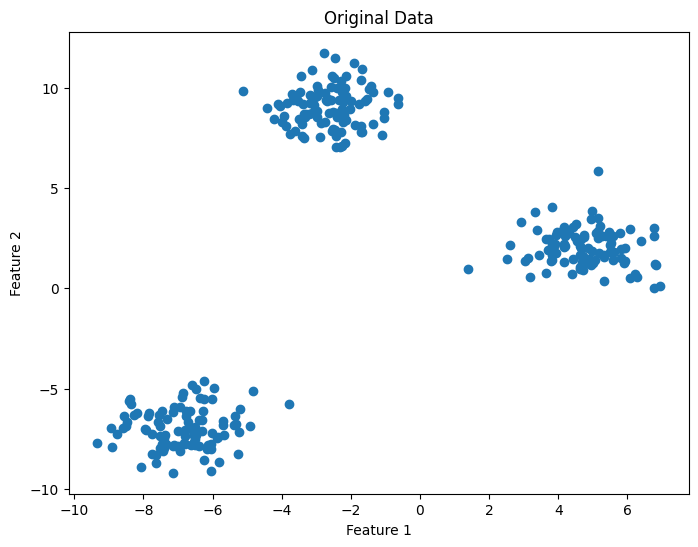

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Feature_1"], df["Feature_2"])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data")
plt.show()

## 12. Huấn luyện K-means

Ta chọn:

\[
K = 3
\]

vì dữ liệu giả lập được tạo với 3 cụm.

In [4]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


Sau khi train xong, ta lấy:

- `labels_`: cluster của từng điểm
- `cluster_centers_`: tọa độ centroid

In [5]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

df["Cluster"] = labels

df.head()

,Feature_1,Feature_2,Cluster
0,-7.338988,-7.729954,1
1,-7.740041,-7.264665,1
2,-1.686653,7.793442,0
3,4.422198,3.071947,2
4,-8.917752,-7.888196,1


## 13. Xem centroid

Mỗi hàng dưới đây là một centroid.

Vì dữ liệu có 2 features, mỗi centroid có dạng:

$$
(\mu_x, \mu_y)
$$

In [6]:
centroid_df = pd.DataFrame(
    centroids,
    columns=["Centroid_Feature_1", "Centroid_Feature_2"]
)

centroid_df

,Centroid_Feature_1,Centroid_Feature_2
0,-2.633233,9.043570
1,-6.883872,-6.983984
2,4.747103,2.010594


## 14. Vẽ kết quả clustering

Các điểm cùng màu thuộc cùng một cluster.  
Dấu `X` là centroid.

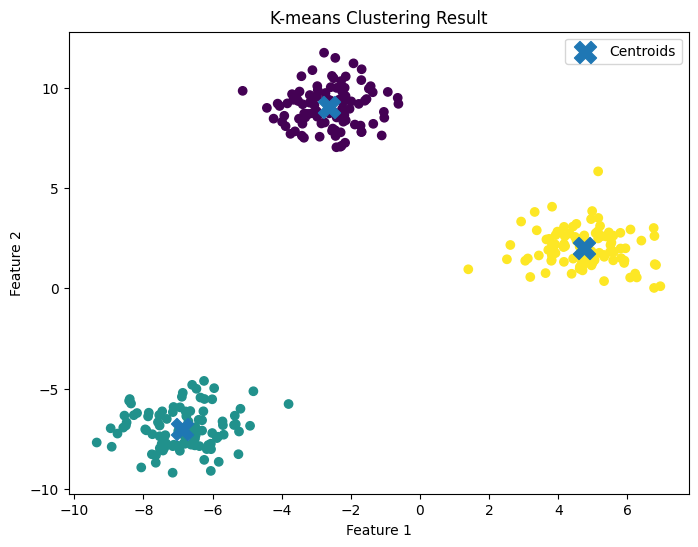

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Feature_1"],
    df["Feature_2"],
    c=df["Cluster"]
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-means Clustering Result")
plt.legend()
plt.show()

## 15. Dự đoán cluster cho điểm mới

Giả sử có điểm mới:

$$
x_{\text{new}} = (0,5)
$$

K-means sẽ xem điểm này gần centroid nào nhất rồi gán vào cluster đó.

In [8]:
new_point = np.array([[0, 5]])

predicted_cluster = kmeans.predict(new_point)

print("New point belongs to cluster:", predicted_cluster[0])

New point belongs to cluster: 0


## 16. Inertia là gì?

Trong scikit-learn, `inertia_` chính là tổng khoảng cách bình phương từ các điểm đến centroid của cluster tương ứng.

Công thức:

$$
\text{Inertia} = \sum_{k=1}^{K}\sum_{x_i \in C_k} ||x_i - \mu_k||^2
$$

Inertia càng nhỏ thì các điểm càng gần centroid.

Tuy nhiên, nếu tăng $K$, inertia gần như luôn giảm.  
Vì vậy ta không thể chỉ chọn K có inertia nhỏ nhất.

In [9]:
print("Inertia:", kmeans.inertia_)

Inertia: 566.8595511244131


## 17. Chọn K bằng Elbow Method

**Elbow Method** thử nhiều giá trị K khác nhau rồi vẽ inertia.

Ý tưởng:

- Khi K tăng, inertia giảm
- Nhưng đến một điểm nào đó, inertia giảm chậm lại
- Điểm đó giống cái khuỷu tay, gọi là **elbow**
- K tại điểm elbow thường là lựa chọn hợp lý

Công thức inertia:

$$
J = \sum_{k=1}^{K}\sum_{x_i \in C_k} ||x_i - \mu_k||^2
$$

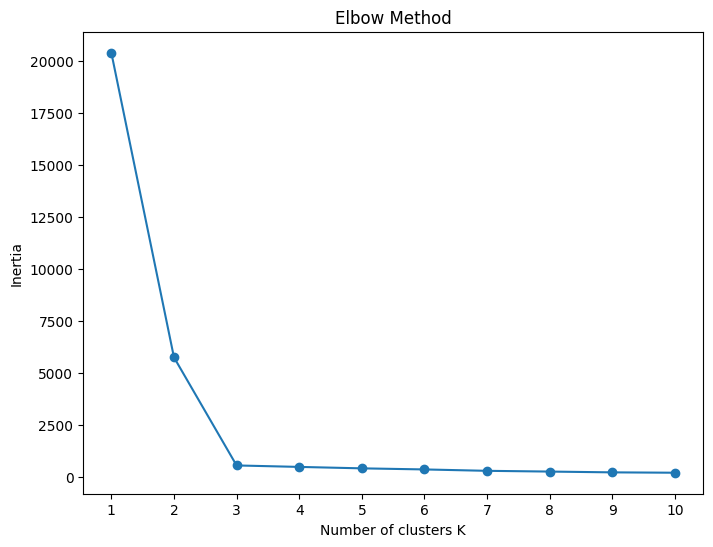

In [10]:
inertias = []

K_range = range(1, 11)

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(K_range)
plt.show()

### Cách đọc Elbow Method

Nếu biểu đồ giảm mạnh từ:

\[
K = 1
\]

đến:

\[
K = 3
\]

sau đó giảm chậm hơn, thì:

\[
K = 3
\]

có thể là lựa chọn tốt.

Nói dễ hiểu:

> Chọn điểm mà từ đó trở đi thêm cluster không giúp cải thiện quá nhiều nữa.

## 18. Chọn K bằng Silhouette Score

**Silhouette Score** đo chất lượng clustering.

Nó kiểm tra:

1. Một điểm có gần các điểm trong cùng cluster không?
2. Một điểm có xa các điểm ở cluster khác không?

Giá trị nằm trong khoảng:

$$
-1 \leq s(i) \leq 1
$$

Công thức Silhouette cho một điểm $i$:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Trong đó:

- $a(i)$: khoảng cách trung bình từ điểm $i$ đến các điểm trong cùng cluster
- $b(i)$: khoảng cách trung bình nhỏ nhất từ điểm $i$ đến các điểm ở cluster khác

Ý nghĩa:

- Gần $1$: clustering tốt
- Gần $0$: điểm nằm giữa các cluster
- Gần $-1$: điểm có thể bị gán sai cluster

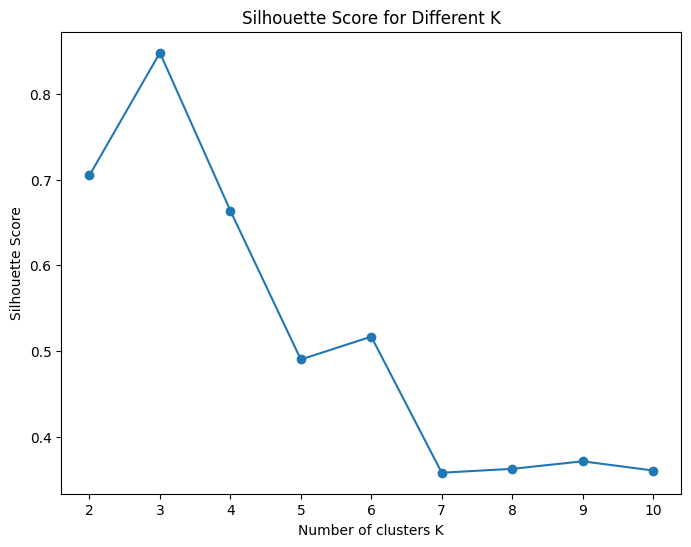

In [11]:
scores = []

K_range = range(2, 11)

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.figure(figsize=(8, 6))
plt.plot(K_range, scores, marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")
plt.xticks(K_range)
plt.show()

### Cách đọc Silhouette Score

K tốt thường là K có Silhouette Score cao.

Ví dụ nếu:

\[
K = 3
\]

có score cao nhất, thì ta có thể chọn:

\[
K = 3
\]

## 19. Vì sao cần StandardScaler?

K-means dựa trên khoảng cách.

Nếu các feature có scale quá khác nhau, feature có giá trị lớn hơn sẽ ảnh hưởng mạnh hơn.

Ví dụ:

$$
\text{Age}: 18 \rightarrow 60
$$

$$
\text{Income}: 1000 \rightarrow 100000
$$

Feature `Income` lớn hơn rất nhiều, nên khoảng cách sẽ bị chi phối bởi `Income`.

Vì vậy, ta thường chuẩn hóa dữ liệu bằng **StandardScaler**.

Công thức chuẩn hóa:

$$
z = \frac{x - \mu}{\sigma}
$$

Trong đó:

- $x$: giá trị ban đầu
- $\mu$: mean
- $\sigma$: standard deviation
- $z$: giá trị sau khi chuẩn hóa

Sau chuẩn hóa, dữ liệu thường có:

$$
\\mu \\approx 0
$$

$$
\\sigma \\approx 1
$$

## 20. Demo 2: Customer Segmentation

Giả sử ta có dữ liệu khách hàng gồm:

- `Annual_Income`: thu nhập hằng năm
- `Spending_Score`: điểm chi tiêu

Mục tiêu:

> Chia khách hàng thành các nhóm có hành vi tương tự nhau.

In [12]:
customer_data = {
    "Customer": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"],
    "Annual_Income": [20, 25, 80, 85, 30, 28, 90, 88, 45, 48],
    "Spending_Score": [80, 75, 20, 15, 70, 72, 18, 22, 50, 55]
}

customer_df = pd.DataFrame(customer_data)

customer_df

,Customer,Annual_Income,Spending_Score
0,A,20,80
1,B,25,75
2,C,80,20
3,D,85,15
4,E,30,70
5,F,28,72
6,G,90,18
7,H,88,22
8,I,45,50
9,J,48,55


## 21. Chọn features và chuẩn hóa dữ liệu

In [13]:
X_customer = customer_df[["Annual_Income", "Spending_Score"]]

scaler = StandardScaler()
X_customer_scaled = scaler.fit_transform(X_customer)

X_customer_scaled[:5]

array([[-1.24159166,  1.28542515],
       [-1.05846605,  1.08644293],
       [ 0.9559157 , -1.10236151],
       [ 1.13904132, -1.30134373],
       [-0.87534043,  0.88746071]])

## 22. Train K-means cho customer segmentation

Ở đây ta thử chọn:

\[
K = 3
\]

Lý do: nhìn dữ liệu có thể chia thành 3 nhóm tương đối rõ:

1. Thu nhập thấp, chi tiêu cao
2. Thu nhập cao, chi tiêu thấp
3. Nhóm trung bình

In [14]:
customer_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = customer_kmeans.fit_predict(X_customer_scaled)

customer_df

,Customer,Annual_Income,Spending_Score,Cluster
0,A,20,80,2
1,B,25,75,2
2,C,80,20,0
3,D,85,15,0
4,E,30,70,2
5,F,28,72,2
6,G,90,18,0
7,H,88,22,0
8,I,45,50,1
9,J,48,55,1


## 23. Vẽ kết quả customer segmentation

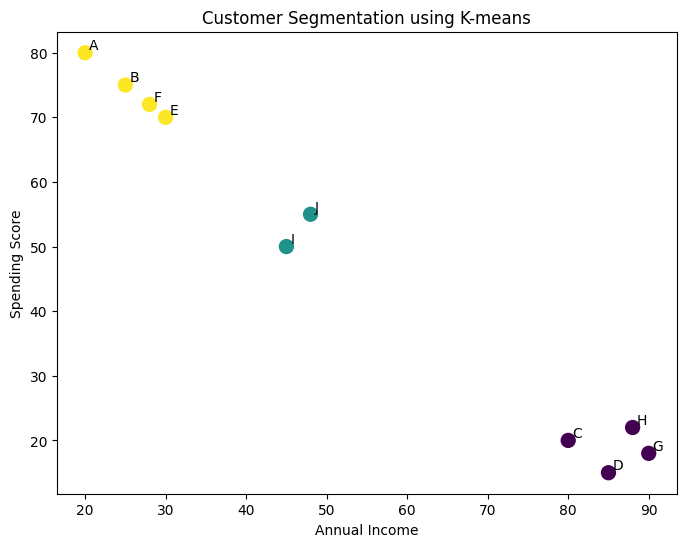

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    customer_df["Annual_Income"],
    customer_df["Spending_Score"],
    c=customer_df["Cluster"],
    s=100
)

for i in range(len(customer_df)):
    plt.text(
        customer_df.loc[i, "Annual_Income"] + 0.5,
        customer_df.loc[i, "Spending_Score"] + 0.5,
        customer_df.loc[i, "Customer"]
    )

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-means")
plt.show()

## 24. Diễn giải kết quả cluster

Sau khi có cluster, ta nên xem trung bình của từng nhóm.

Điều này giúp ta hiểu mỗi cluster đại diện cho kiểu khách hàng nào.

In [16]:
cluster_summary = customer_df.groupby("Cluster")[["Annual_Income", "Spending_Score"]].mean()

cluster_summary

,Annual_Income,Spending_Score
Cluster,,
0,85.75,18.75
1,46.50,52.50
2,25.75,74.25


Ví dụ cách diễn giải:

- Cluster có `Annual_Income` thấp và `Spending_Score` cao  
  → nhóm thu nhập thấp nhưng chi tiêu mạnh

- Cluster có `Annual_Income` cao và `Spending_Score` thấp  
  → nhóm thu nhập cao nhưng chi tiêu thấp

- Cluster có cả hai chỉ số ở mức trung bình  
  → nhóm khách hàng trung bình

Lưu ý:

> Số cluster như 0, 1, 2 chỉ là tên nhóm.  
> Nó không có nghĩa cluster 2 tốt hơn cluster 1.

## 25. Ưu điểm của K-means

K-means có các ưu điểm sau:

1. Dễ hiểu
2. Dễ triển khai bằng Python
3. Chạy nhanh
4. Phù hợp với dữ liệu lớn
5. Dễ trực quan hóa nếu dữ liệu có 2 hoặc 3 features
6. Hữu ích trong customer segmentation, market segmentation, image compression

---

## 26. Nhược điểm của K-means

K-means có các nhược điểm sau:

1. Phải chọn trước số cụm $K$
2. Nhạy với outliers
3. Nhạy với scale của dữ liệu
4. Không tốt với cluster có hình dạng phức tạp
5. Kết quả có thể phụ thuộc vào centroid ban đầu
6. Chủ yếu phù hợp với dữ liệu dạng số

Ví dụ, nếu dữ liệu có dạng vòng tròn hoặc hình cong, K-means thường hoạt động không tốt.

## 27. Khi nào nên dùng K-means?

Nên dùng K-means khi:

- Dữ liệu không có label
- Muốn chia nhóm dữ liệu
- Features chủ yếu là numerical
- Các cluster có dạng tương đối tròn/gọn
- Cần một thuật toán đơn giản, nhanh, dễ giải thích

Không nên dùng K-means khi:

- Dữ liệu có quá nhiều outliers
- Cluster có hình dạng phức tạp
- Dữ liệu chủ yếu là categorical
- Không biết chọn $K$
- Scale giữa các features quá khác nhau mà chưa chuẩn hóa

## 28. K-means trong một câu tiếng Anh

> K-means is an unsupervised learning algorithm used for clustering. It groups similar data points into K clusters by assigning each point to the nearest centroid and repeatedly updating the centroids until the clusters become stable.

Dịch tiếng Việt:

> K-means là thuật toán học không giám sát dùng để phân cụm. Nó chia các điểm dữ liệu tương tự nhau thành K cụm bằng cách gán mỗi điểm vào centroid gần nhất và liên tục cập nhật centroid cho đến khi các cụm ổn định.

## 29. Từ vựng quan trọng

| English | Vietnamese Meaning |
|---|---|
| K-means | Thuật toán K-means |
| Clustering | Phân cụm |
| Unsupervised Learning | Học không giám sát |
| Cluster | Cụm / nhóm |
| Centroid | Tâm cụm |
| Euclidean Distance | Khoảng cách Euclidean |
| Inertia | Tổng khoảng cách bình phương trong cụm |
| Elbow Method | Phương pháp khuỷu tay |
| Silhouette Score | Điểm Silhouette |
| StandardScaler | Công cụ chuẩn hóa dữ liệu |
| Feature | Đặc trưng / biến đầu vào |
| Outlier | Điểm ngoại lai |

## 30. Bài tập tự luyện

### Bài 1

Cho 4 điểm:

$$
A = (1,1),\quad B = (2,1),\quad C = (8,8),\quad D = (9,8)
$$

Chọn:

$$
K = 2
$$

Hãy dự đoán K-means sẽ chia thành 2 cluster nào.

---

### Bài 2

Cho cluster gồm 3 điểm:

$$
(2,3),\quad (4,5),\quad (6,7)
$$

Hãy tính centroid.

---

### Bài 3

Cho:

$$
A = (3,4)
$$

$$
B = (6,8)
$$

Hãy tính Euclidean Distance giữa A và B.

---

### Bài 4

Giải thích vì sao cần chuẩn hóa dữ liệu trước khi dùng K-means.

---

### Bài 5

Trong customer segmentation, nếu một nhóm có:

$$
\text{Annual Income cao}
$$

và

$$
\text{Spending Score thấp}
$$

thì bạn sẽ diễn giải nhóm khách hàng này như thế nào?

## 31. Đáp án bài tập

### Đáp án bài 1

Có thể chia thành:

\[
C_1 = \{A, B\}
\]

\[
C_2 = \{C, D\}
\]

vì A và B gần nhau, C và D gần nhau.

---

### Đáp án bài 2

Centroid:

\[
\mu_x = \frac{2+4+6}{3} = 4
\]

\[
\mu_y = \frac{3+5+7}{3} = 5
\]

Vậy centroid là:

\[
(4,5)
\]

---

### Đáp án bài 3

\[
d(A,B) = \sqrt{(6-3)^2 + (8-4)^2}
\]

\[
d(A,B) = \sqrt{3^2 + 4^2}
\]

\[
d(A,B) = \sqrt{9+16}
\]

\[
d(A,B) = 5
\]

---

### Đáp án bài 4

Vì K-means dùng khoảng cách.  
Nếu một feature có scale quá lớn, nó sẽ chi phối khoảng cách và làm model bị lệch.

Ví dụ `Income` có scale lớn hơn `Age`, nên nếu không chuẩn hóa, K-means có thể chủ yếu chia nhóm theo `Income`.

---

### Đáp án bài 5

Nhóm này có thể là:

> Khách hàng có thu nhập cao nhưng chi tiêu thấp.

Ý nghĩa kinh doanh:

- Có khả năng mua hàng
- Nhưng hiện tại chưa chi tiêu nhiều
- Có thể cần chiến dịch marketing riêng để kích thích mua hàng